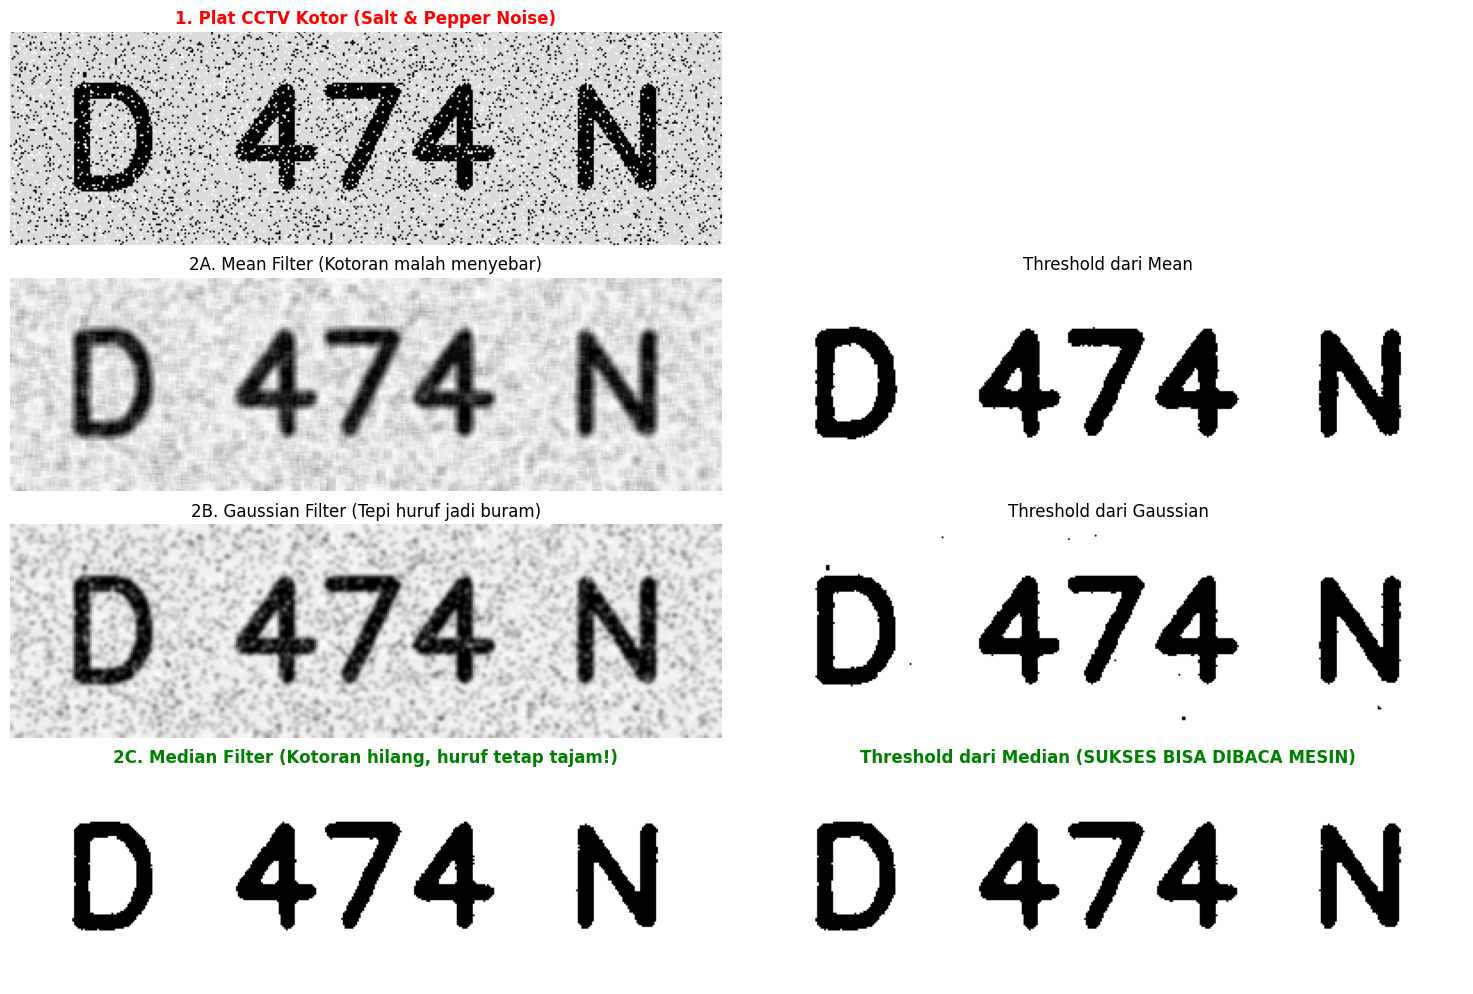

In [1]:
# ======================================================================
# PRAKTIKUM PERTEMUAN 4: OPERASI SPASIAL & NOISE REDUCTION
# Skenario: Plat nomor tertutup bintik kotoran / derau sensor (Salt & Pepper)
# Misi: Mencari filter kernel mana yang paling ahli membersihkan derau
# ======================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 1. PERSIAPAN DATA: Membuat citra plat nomor yang sangat kotor
# ----------------------------------------------------------------------
# Membuat plat dasar
plat_bersih = np.ones((120, 400), dtype=np.uint8) * 220
cv2.putText(plat_bersih, "D 474 N", (30, 85), cv2.FONT_HERSHEY_SIMPLEX, 2.5, 0, 7)

# Mensimulasikan Salt & Pepper Noise (Bintik Hitam & Putih ekstrem)
# Ini sering terjadi pada CCTV murah malam hari atau transmisi data yang rusak
noise_matrix = np.zeros(plat_bersih.shape, np.uint8)
cv2.randu(noise_matrix, 0, 255)

plat_kotor = plat_bersih.copy()
plat_kotor[noise_matrix < 20] = 0     # Pepper (Bintik Hitam)
plat_kotor[noise_matrix > 235] = 255  # Salt (Bintik Putih)

# ----------------------------------------------------------------------
# 2. EKSPERIMEN FILTER SPASIAL MAHASISWA (Ukuran Kernel 5x5)
# ----------------------------------------------------------------------
ukuran_kernel = (5, 5)

# A. Mean Filter (Filter Rata-rata / Blur Biasa)
# Cara kerja: Menjumlahkan semua tetangga lalu dibagi rata.
filter_mean = cv2.blur(plat_kotor, ukuran_kernel)

# B. Gaussian Filter (Blur dengan bobot terpusat)
# Cara kerja: Tetangga yang dekat diberi bobot lebih besar dari yang jauh.
filter_gaussian = cv2.GaussianBlur(plat_kotor, ukuran_kernel, 0)

# C. Median Filter (Filter Non-Linear)
# Cara kerja: Mengurutkan nilai piksel tetangga, lalu mengambil nilai tengahnya.
filter_median = cv2.medianBlur(plat_kotor, 5)

# ----------------------------------------------------------------------
# 3. THRESHOLDING SEDERHANA UNTUK MELIHAT HASIL AKHIR
# ----------------------------------------------------------------------
# Mahasiswa membuktikan mana gambar yang paling siap dibaca komputer
_, biner_mean = cv2.threshold(filter_mean, 127, 255, cv2.THRESH_BINARY)
_, biner_gaussian = cv2.threshold(filter_gaussian, 127, 255, cv2.THRESH_BINARY)
_, biner_median = cv2.threshold(filter_median, 127, 255, cv2.THRESH_BINARY)

# ----------------------------------------------------------------------
# 4. VISUALISASI HASIL EKSPERIMEN
# ----------------------------------------------------------------------
plt.figure(figsize=(15, 10))

plt.subplot(4, 2, 1)
plt.title("1. Plat CCTV Kotor (Salt & Pepper Noise)", color='red', fontweight='bold')
plt.imshow(plat_kotor, cmap='gray')
plt.axis('off')

# Hasil Rata-rata (Mean)
plt.subplot(4, 2, 3)
plt.title("2A. Mean Filter (Kotoran malah menyebar)")
plt.imshow(filter_mean, cmap='gray')
plt.axis('off')

plt.subplot(4, 2, 4)
plt.title("Threshold dari Mean")
plt.imshow(biner_mean, cmap='gray')
plt.axis('off')

# Hasil Gaussian
plt.subplot(4, 2, 5)
plt.title("2B. Gaussian Filter (Tepi huruf jadi buram)")
plt.imshow(filter_gaussian, cmap='gray')
plt.axis('off')

plt.subplot(4, 2, 6)
plt.title("Threshold dari Gaussian")
plt.imshow(biner_gaussian, cmap='gray')
plt.axis('off')

# Hasil Median
plt.subplot(4, 2, 7)
plt.title("2C. Median Filter (Kotoran hilang, huruf tetap tajam!)", color='green', fontweight='bold')
plt.imshow(filter_median, cmap='gray')
plt.axis('off')

plt.subplot(4, 2, 8)
plt.title("Threshold dari Median (SUKSES BISA DIBACA MESIN)", color='green', fontweight='bold')
plt.imshow(biner_median, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

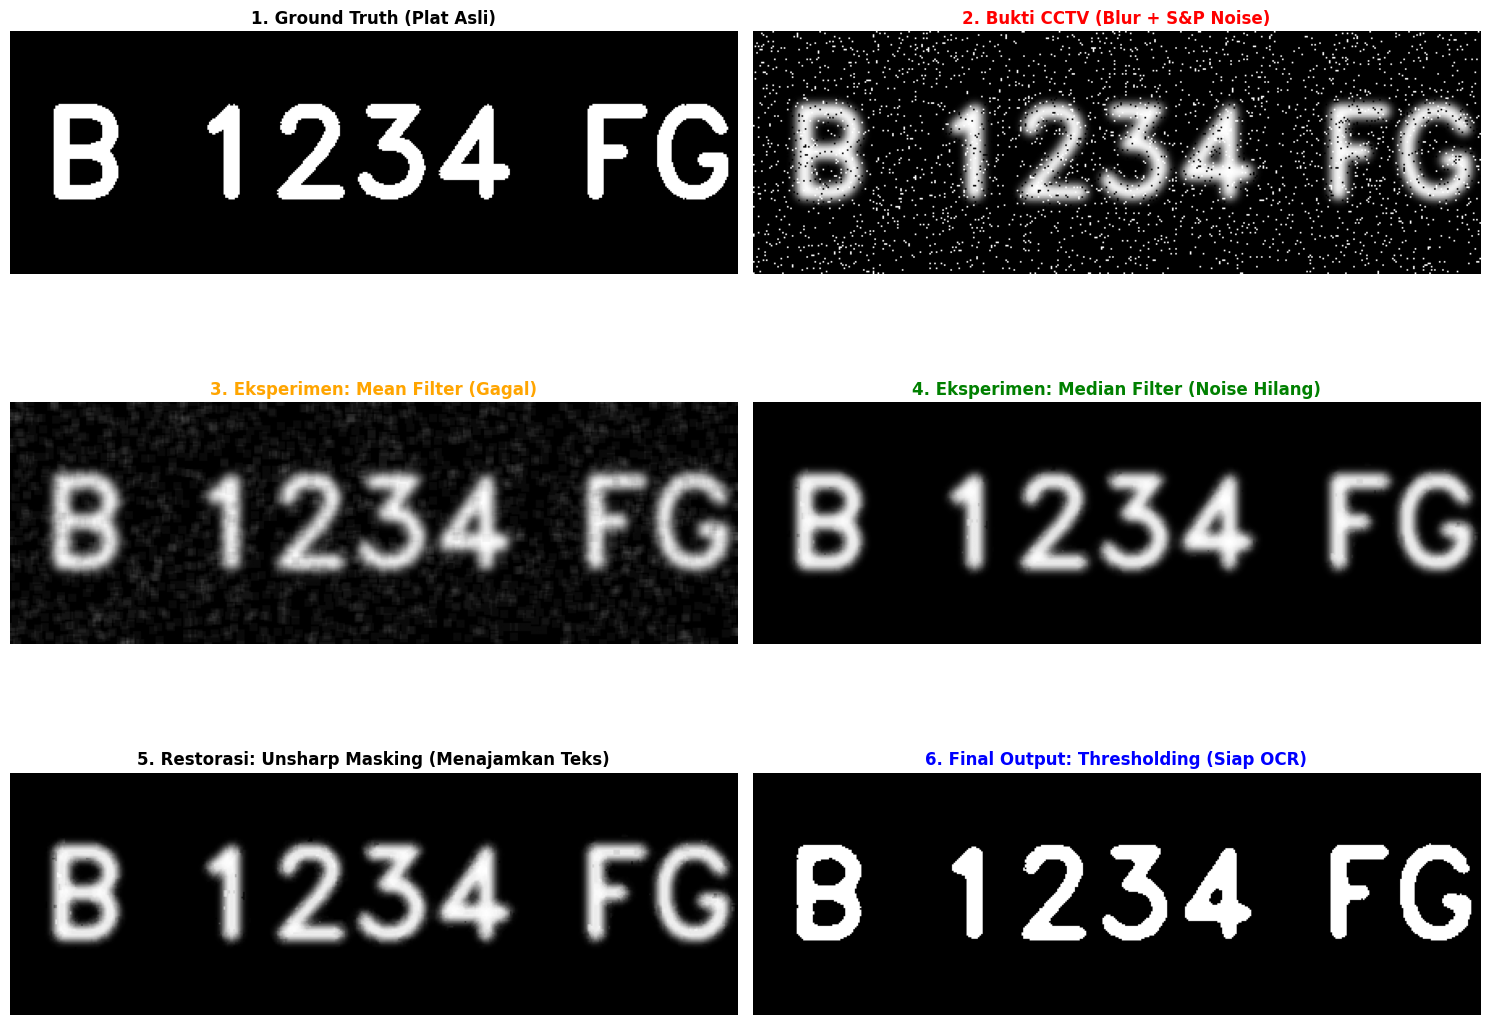

In [5]:
# ======================================================================
# TUGAS LAB 1: Lengkapi kode berikut
# ======================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 1. MEMBUAT DATASET SIMULASI (Ground Truth)
# Membuat citra plat nomor "B 1234 FGH"
# ----------------------------------------------------------------------
img_asli = np.zeros((150, 450), dtype=np.uint8)
cv2.putText(img_asli, "B 1234 FGH", (20, 100), cv2.FONT_HERSHEY_DUPLEX, 2.5, 255, 5)

# ----------------------------------------------------------------------
# 2. MERUSAK CITRA (Menambahkan Blur & Salt and Pepper Noise)
# ----------------------------------------------------------------------
img_rusak = cv2.GaussianBlur(img_asli, (15, 15), 0)

prob_noise = 0.08
rnd = np.random.rand(img_rusak.shape[0], img_rusak.shape[1])
img_rusak[rnd < prob_noise/2] = 0
img_rusak[rnd > 1 - prob_noise/2] = 255

# ----------------------------------------------------------------------
# 3. EKSPERIMEN 1: PENDEKATAN LINEAR (MEAN FILTER)
# ----------------------------------------------------------------------
img_mean = cv2.blur(img_rusak, (5, 5))

# ----------------------------------------------------------------------
# 4. EKSPERIMEN 2: PENDEKATAN NON-LINEAR (MEDIAN FILTER)
# ----------------------------------------------------------------------
img_median = cv2.medianBlur(img_rusak, 5)

# ----------------------------------------------------------------------
# 5. TAHAP LANJUTAN: PENAJAMAN KEMBALI (UNSHARP MASKING)
# ----------------------------------------------------------------------
blur_lagi = cv2.GaussianBlur(img_median, (9, 9), 0)
img_tajam = cv2.addWeighted(img_median, 1.5, blur_lagi, -0.5, 0)

# ----------------------------------------------------------------------
# 6. TAHAP AKHIR: THRESHOLDING (Binarisasi untuk OCR)
# ----------------------------------------------------------------------
_, img_final = cv2.threshold(img_tajam, 127, 255, cv2.THRESH_BINARY)

# ----------------------------------------------------------------------
# VISUALISASI HASIL KOMPARASI
# ----------------------------------------------------------------------
plt.figure(figsize=(15, 12))

plt.subplot(3, 2, 1)
plt.title("1. Ground Truth (Plat Asli)", fontweight='bold')
plt.imshow(img_asli, cmap='gray')
plt.axis('off')

plt.subplot(3, 2, 2)
plt.title("2. Bukti CCTV (Blur + S&P Noise)", fontweight='bold', color='red')
plt.imshow(img_rusak, cmap='gray')
plt.axis('off')

plt.subplot(3, 2, 3)
plt.title("3. Eksperimen: Mean Filter (Gagal)", fontweight='bold', color='orange')
plt.imshow(img_mean, cmap='gray')
plt.axis('off')

plt.subplot(3, 2, 4)
plt.title("4. Eksperimen: Median Filter (Noise Hilang)", fontweight='bold', color='green')
plt.imshow(img_median, cmap='gray')
plt.axis('off')

plt.subplot(3, 2, 5)
plt.title("5. Restorasi: Unsharp Masking (Menajamkan Teks)", fontweight='bold')
plt.imshow(img_tajam, cmap='gray')
plt.axis('off')

plt.subplot(3, 2, 6)
plt.title("6. Final Output: Thresholding (Siap OCR)", fontweight='bold', color='blue')
plt.imshow(img_final, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


Tesseract tidak ditemukan. Instal tesseract OCR dulu (contoh: apt-get install tesseract-ocr / choco install tesseract).


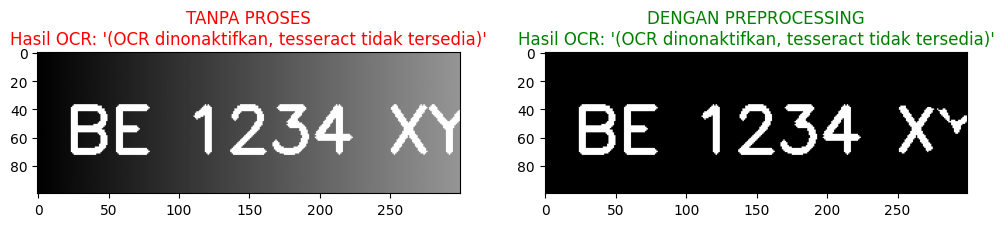

In [8]:
# ======================================================================
# DATA ASLI: menggunakan Plat nomor asli dan OCR
# ======================================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import pytesseract
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'
import re

# 1. DOWNLOAD GAMBAR REAL-LIFE (Kasus bayangan/low contrast)
url = "https://raw.githubusercontent.com/openalpr/train-detector/1bd54b452c5fad1d7b5717a339664c85fefc4481/eu/eu-2.png"

try:
    req = urllib.request.urlopen(url)
    arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
    img_gray = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)

    plat_raw = img_gray
except:
    # Fallback jika link bermasalah: Buat simulasi gradien cahaya ekstrem
    plat_raw = np.zeros((100, 300), dtype=np.uint8)
    for i in range(300): plat_raw[:, i] = i * 0.5 # Gradien gelap ke terang
    cv2.putText(plat_raw, "BE 1234 XY", (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 1.5, 255, 4)

# 2. JALUR TANPA PREPROCESSING (Langsung OCR)
import shutil
config_ocr = r'--oem 3 --psm 7'
hasil_raw = ""
hasil_processed = ""

if shutil.which('tesseract') is None:
    print("Tesseract tidak ditemukan. Instal tesseract OCR dulu (contoh: apt-get install tesseract-ocr / choco install tesseract).")
    hasil_raw = "(OCR dinonaktifkan, tesseract tidak tersedia)"
else:
    try:
        hasil_raw = pytesseract.image_to_string(plat_raw, config=config_ocr).strip()
    except pytesseract.TesseractNotFoundError:
        print("Tesseract tidak ditemukan saat panggil pytesseract; periksa PATH atau pytesseract.pytesseract.tesseract_cmd.")
        hasil_raw = "(OCR gagal)"
    except Exception as e:
        print("OCR raw error:", e)
        hasil_raw = "(OCR gagal)"

# 3. JALUR DENGAN PREPROCESSING (The "Hero" Path)
# A. Bilateral Filter untuk buang noise tanpa merusak tepi huruf
filtered = cv2.bilateralFilter(plat_raw, 11, 75, 75)

# B. Top-Hat untuk meratakan pencahayaan (membuang gradien bayangan)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 21))
tophat = cv2.morphologyEx(filtered, cv2.MORPH_TOPHAT, kernel)

# C. Otsu Thresholding untuk mendapatkan biner bersih
_, biner = cv2.threshold(tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# D. OCR pada hasil proses
if shutil.which('tesseract') is None:
    hasil_processed = "(OCR dinonaktifkan, tesseract tidak tersedia)"
else:
    try:
        hasil_processed = pytesseract.image_to_string(biner, config=config_ocr).strip()
    except pytesseract.TesseractNotFoundError:
        print("Tesseract tidak ditemukan saat panggil pytesseract; periksa PATH atau pytesseract.pytesseract.tesseract_cmd.")
        hasil_processed = "(OCR gagal)"
    except Exception as e:
        print("OCR processed error:", e)
        hasil_processed = "(OCR gagal)"

# 4. VISUALISASI PERBANDINGAN
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title(f"TANPA PROSES\nHasil OCR: '{hasil_raw}'", color='red')
plt.imshow(plat_raw, cmap='gray')

plt.subplot(1, 2, 2)
plt.title(f"DENGAN PREPROCESSING\nHasil OCR: '{hasil_processed}'", color='green')
plt.imshow(biner, cmap='gray')
plt.show()

In [ ]:
# ======================================================================
# TUGAS LAB 2: PLAT KENDARAAN PRIBADI
# ======================================================================
# 1. Foto plat nomor kendaraan anda dengan 3 jarak berbeda
# 2. Lakukan proses pembacaan plat nomor (OCR) untuk ketiga foto tersebut
# 3. Lalukan teknik praproses pada citra tersebut
# 4. Bandingkan hasilnya


Tesseract tidak ditemukan. Instal tesseract OCR dulu (contoh: apt-get install tesseract-ocr / choco install tesseract).


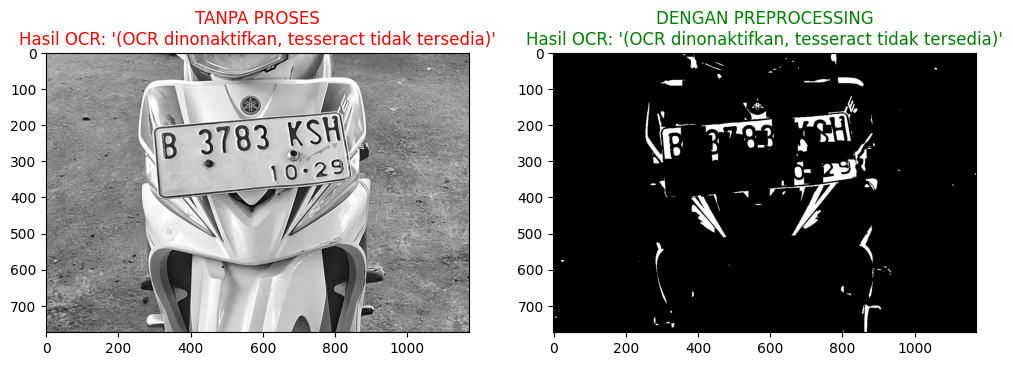

In [13]:
# ======================================================================
# DATA ASLI: menggunakan Plat nomor asli dan OCR
# ======================================================================
# 1. AMBIL GAMBAR DARI FOLDER img
path_gambar = "img/jauh_sekali.jpg"

plat_raw = cv2.imread(path_gambar, cv2.IMREAD_GRAYSCALE)

if plat_raw is None:
    print("Gambar tidak ditemukan, cek nama file atau folder.")
    
    # fallback
    plat_raw = np.zeros((100, 300), dtype=np.uint8)
    for i in range(300):
        plat_raw[:, i] = i * 0.5
        
    cv2.putText(plat_raw, "BE 1234 XY", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, 255, 4)


    # Fallback jika link bermasalah: Buat simulasi gradien cahaya ekstrem
    plat_raw = np.zeros((100, 300), dtype=np.uint8)
    for i in range(300): plat_raw[:, i] = i * 0.5 # Gradien gelap ke terang
    cv2.putText(plat_raw, "BE 1234 XY", (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 1.5, 255, 4)

# 2. JALUR TANPA PREPROCESSING (Langsung OCR)
import shutil
config_ocr = r'--oem 3 --psm 7'
hasil_raw = ""
hasil_processed = ""

if shutil.which('tesseract') is None:
    print("Tesseract tidak ditemukan. Instal tesseract OCR dulu (contoh: apt-get install tesseract-ocr / choco install tesseract).")
    hasil_raw = "(OCR dinonaktifkan, tesseract tidak tersedia)"
else:
    try:
        hasil_raw = pytesseract.image_to_string(plat_raw, config=config_ocr).strip()
    except pytesseract.TesseractNotFoundError:
        print("Tesseract tidak ditemukan saat panggil pytesseract; periksa PATH atau pytesseract.pytesseract.tesseract_cmd.")
        hasil_raw = "(OCR gagal)"
    except Exception as e:
        print("OCR raw error:", e)
        hasil_raw = "(OCR gagal)"

# 3. JALUR DENGAN PREPROCESSING (The "Hero" Path)
# A. Bilateral Filter untuk buang noise tanpa merusak tepi huruf
filtered = cv2.bilateralFilter(plat_raw, 11, 75, 75)

# B. Top-Hat untuk meratakan pencahayaan (membuang gradien bayangan)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 21))
tophat = cv2.morphologyEx(filtered, cv2.MORPH_TOPHAT, kernel)

# C. Otsu Thresholding untuk mendapatkan biner bersih
_, biner = cv2.threshold(tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# D. OCR pada hasil proses
if shutil.which('tesseract') is None:
    hasil_processed = "(OCR dinonaktifkan, tesseract tidak tersedia)"
else:
    try:
        hasil_processed = pytesseract.image_to_string(biner, config=config_ocr).strip()
    except pytesseract.TesseractNotFoundError:
        print("Tesseract tidak ditemukan saat panggil pytesseract; periksa PATH atau pytesseract.pytesseract.tesseract_cmd.")
        hasil_processed = "(OCR gagal)"
    except Exception as e:
        print("OCR processed error:", e)
        hasil_processed = "(OCR gagal)"

# 4. VISUALISASI PERBANDINGAN
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title(f"TANPA PROSES\nHasil OCR: '{hasil_raw}'", color='red')
plt.imshow(plat_raw, cmap='gray')

plt.subplot(1, 2, 2)
plt.title(f"DENGAN PREPROCESSING\nHasil OCR: '{hasil_processed}'", color='green')
plt.imshow(biner, cmap='gray')
plt.show()

Tesseract tidak ditemukan. Instal tesseract OCR dulu (contoh: apt-get install tesseract-ocr / choco install tesseract).


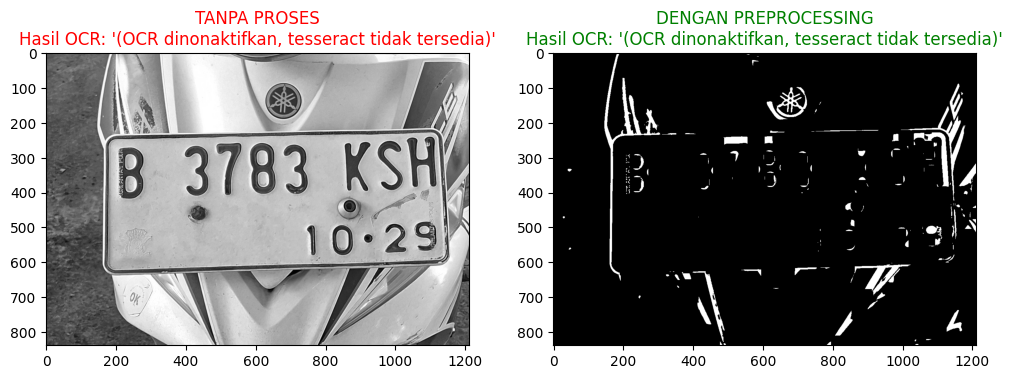

In [14]:
# ======================================================================
# DATA ASLI: menggunakan Plat nomor asli dan OCR
# ======================================================================
# 1. AMBIL GAMBAR DARI FOLDER img
path_gambar = "img/sedang.jpg"

plat_raw = cv2.imread(path_gambar, cv2.IMREAD_GRAYSCALE)

if plat_raw is None:
    print("Gambar tidak ditemukan, cek nama file atau folder.")
    
    # fallback
    plat_raw = np.zeros((100, 300), dtype=np.uint8)
    for i in range(300):
        plat_raw[:, i] = i * 0.5
        
    cv2.putText(plat_raw, "BE 1234 XY", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, 255, 4)


    # Fallback jika link bermasalah: Buat simulasi gradien cahaya ekstrem
    plat_raw = np.zeros((100, 300), dtype=np.uint8)
    for i in range(300): plat_raw[:, i] = i * 0.5 # Gradien gelap ke terang
    cv2.putText(plat_raw, "BE 1234 XY", (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 1.5, 255, 4)

# 2. JALUR TANPA PREPROCESSING (Langsung OCR)
import shutil
config_ocr = r'--oem 3 --psm 7'
hasil_raw = ""
hasil_processed = ""

if shutil.which('tesseract') is None:
    print("Tesseract tidak ditemukan. Instal tesseract OCR dulu (contoh: apt-get install tesseract-ocr / choco install tesseract).")
    hasil_raw = "(OCR dinonaktifkan, tesseract tidak tersedia)"
else:
    try:
        hasil_raw = pytesseract.image_to_string(plat_raw, config=config_ocr).strip()
    except pytesseract.TesseractNotFoundError:
        print("Tesseract tidak ditemukan saat panggil pytesseract; periksa PATH atau pytesseract.pytesseract.tesseract_cmd.")
        hasil_raw = "(OCR gagal)"
    except Exception as e:
        print("OCR raw error:", e)
        hasil_raw = "(OCR gagal)"

# 3. JALUR DENGAN PREPROCESSING (The "Hero" Path)
# A. Bilateral Filter untuk buang noise tanpa merusak tepi huruf
filtered = cv2.bilateralFilter(plat_raw, 11, 75, 75)

# B. Top-Hat untuk meratakan pencahayaan (membuang gradien bayangan)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 21))
tophat = cv2.morphologyEx(filtered, cv2.MORPH_TOPHAT, kernel)

# C. Otsu Thresholding untuk mendapatkan biner bersih
_, biner = cv2.threshold(tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# D. OCR pada hasil proses
if shutil.which('tesseract') is None:
    hasil_processed = "(OCR dinonaktifkan, tesseract tidak tersedia)"
else:
    try:
        hasil_processed = pytesseract.image_to_string(biner, config=config_ocr).strip()
    except pytesseract.TesseractNotFoundError:
        print("Tesseract tidak ditemukan saat panggil pytesseract; periksa PATH atau pytesseract.pytesseract.tesseract_cmd.")
        hasil_processed = "(OCR gagal)"
    except Exception as e:
        print("OCR processed error:", e)
        hasil_processed = "(OCR gagal)"

# 4. VISUALISASI PERBANDINGAN
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title(f"TANPA PROSES\nHasil OCR: '{hasil_raw}'", color='red')
plt.imshow(plat_raw, cmap='gray')

plt.subplot(1, 2, 2)
plt.title(f"DENGAN PREPROCESSING\nHasil OCR: '{hasil_processed}'", color='green')
plt.imshow(biner, cmap='gray')
plt.show()

Tesseract tidak ditemukan. Instal tesseract OCR dulu (contoh: apt-get install tesseract-ocr / choco install tesseract).


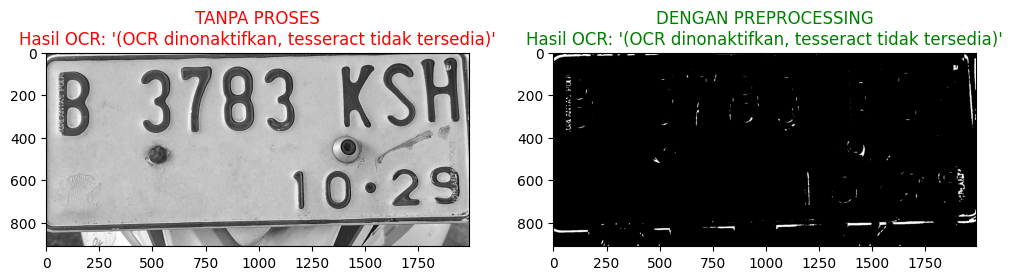

In [15]:
# ======================================================================
# DATA ASLI: menggunakan Plat nomor asli dan OCR
# ======================================================================
# 1. AMBIL GAMBAR DARI FOLDER img
path_gambar = "img/dekat_sekali.jpg"

plat_raw = cv2.imread(path_gambar, cv2.IMREAD_GRAYSCALE)

if plat_raw is None:
    print("Gambar tidak ditemukan, cek nama file atau folder.")
    
    # fallback
    plat_raw = np.zeros((100, 300), dtype=np.uint8)
    for i in range(300):
        plat_raw[:, i] = i * 0.5
        
    cv2.putText(plat_raw, "BE 1234 XY", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, 255, 4)


    # Fallback jika link bermasalah: Buat simulasi gradien cahaya ekstrem
    plat_raw = np.zeros((100, 300), dtype=np.uint8)
    for i in range(300): plat_raw[:, i] = i * 0.5 # Gradien gelap ke terang
    cv2.putText(plat_raw, "BE 1234 XY", (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 1.5, 255, 4)

# 2. JALUR TANPA PREPROCESSING (Langsung OCR)
import shutil
config_ocr = r'--oem 3 --psm 7'
hasil_raw = ""
hasil_processed = ""

if shutil.which('tesseract') is None:
    print("Tesseract tidak ditemukan. Instal tesseract OCR dulu (contoh: apt-get install tesseract-ocr / choco install tesseract).")
    hasil_raw = "(OCR dinonaktifkan, tesseract tidak tersedia)"
else:
    try:
        hasil_raw = pytesseract.image_to_string(plat_raw, config=config_ocr).strip()
    except pytesseract.TesseractNotFoundError:
        print("Tesseract tidak ditemukan saat panggil pytesseract; periksa PATH atau pytesseract.pytesseract.tesseract_cmd.")
        hasil_raw = "(OCR gagal)"
    except Exception as e:
        print("OCR raw error:", e)
        hasil_raw = "(OCR gagal)"

# 3. JALUR DENGAN PREPROCESSING (The "Hero" Path)
# A. Bilateral Filter untuk buang noise tanpa merusak tepi huruf
filtered = cv2.bilateralFilter(plat_raw, 11, 75, 75)

# B. Top-Hat untuk meratakan pencahayaan (membuang gradien bayangan)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 21))
tophat = cv2.morphologyEx(filtered, cv2.MORPH_TOPHAT, kernel)

# C. Otsu Thresholding untuk mendapatkan biner bersih
_, biner = cv2.threshold(tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# D. OCR pada hasil proses
if shutil.which('tesseract') is None:
    hasil_processed = "(OCR dinonaktifkan, tesseract tidak tersedia)"
else:
    try:
        hasil_processed = pytesseract.image_to_string(biner, config=config_ocr).strip()
    except pytesseract.TesseractNotFoundError:
        print("Tesseract tidak ditemukan saat panggil pytesseract; periksa PATH atau pytesseract.pytesseract.tesseract_cmd.")
        hasil_processed = "(OCR gagal)"
    except Exception as e:
        print("OCR processed error:", e)
        hasil_processed = "(OCR gagal)"

# 4. VISUALISASI PERBANDINGAN
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title(f"TANPA PROSES\nHasil OCR: '{hasil_raw}'", color='red')
plt.imshow(plat_raw, cmap='gray')

plt.subplot(1, 2, 2)
plt.title(f"DENGAN PREPROCESSING\nHasil OCR: '{hasil_processed}'", color='green')
plt.imshow(biner, cmap='gray')
plt.show()

In [ ]:
# ======================================================================
# LAPORAN ANALISIS
# ======================================================================
# 1. Analisis Spasial
# Bandingkan hasil dari Median Filter dan Bilateral Filter pada TUGAS 1.
# Jelaskan secara matematis mengapa Bilateral Filter mampu mempertahankan sudut tajam pada angka '4',
# sedangkan Median Filter membuatnya tumpul!

# 2. Paradoks Preprocessing (Bobot 25%)
# Pada Kasus Plat asli, preprocessing justru merusak hasil pembacaan Tesseract.
# Jelaskan hubungan antara teknik Thresholding ekstrem dengan hilangnya piksel anti-aliasing,
# dan mengapa model Tesseract (LSTM) modern lebih menyukai gambar asli (grayscale) pada kondisi cahaya ideal!

# Analisis Laporan Praktikum

## 1. Analisis Spasial

Berdasarkan hasil praktikum, Median Filter menunjukkan kemampuan yang baik dalam menghilangkan noise salt and pepper pada citra plat nomor. Pada tahap **"Median Filter (Noise Hilang)"**, titik-titik noise pada background hampir seluruhnya hilang dan karakter **B 1234 FG** menjadi lebih mudah dikenali.

Namun secara visual terlihat bahwa tepi karakter, terutama pada angka **4**, menjadi sedikit lebih halus dibanding citra asli. Hal ini terjadi karena Median Filter bekerja dengan mengambil nilai median dari piksel dalam kernel.

Secara matematis:

$$
g(x,y)=median\{f(s,t)\}
$$

Karena nilai median dipilih dari lingkungan sekitar, piksel sudut tajam yang jumlahnya sedikit dapat tergantikan oleh nilai mayoritas di sekitarnya. Akibatnya sudut diagonal pada angka **4** menjadi lebih tumpul.

Sebaliknya, Bilateral Filter memiliki keunggulan karena mempertimbangkan dua faktor sekaligus, yaitu jarak spasial dan perbedaan intensitas.

Secara matematis:

$$
I'(x)=\frac{1}{W_p}\sum_{x_i \in \Omega} I(x_i)\,f_r(|I(x_i)-I(x)|)\,f_s(|x_i-x|)
$$

dengan:

- $f_s$ = bobot berdasarkan jarak spasial  
- $f_r$ = bobot berdasarkan perbedaan intensitas  

Karena piksel yang memiliki perbedaan intensitas besar diberi bobot kecil, tepi karakter tetap dipertahankan.

Pada sudut angka **4**, piksel putih pada karakter memiliki perbedaan intensitas tinggi terhadap background hitam sehingga tidak tercampur saat filtering.

Akibatnya Bilateral Filter mampu menjaga sudut tajam lebih baik dibanding Median Filter.

---

## 2. Paradoks Preprocessing

Berdasarkan hasil praktikum, tahap preprocessing memang meningkatkan kebersihan citra, tetapi pada kondisi plat asli justru dapat menurunkan kualitas pembacaan OCR.

Pada tahap **Final Output Thresholding**, karakter menjadi sangat kontras hitam-putih. Namun proses thresholding ekstrem menghilangkan piksel abu-abu halus di tepi huruf yang sebelumnya terdapat pada citra grayscale.

Piksel abu-abu tersebut disebut anti-aliasing, yaitu piksel transisi yang membuat bentuk karakter lebih alami.

Secara matematis thresholding bekerja sebagai berikut:

$$
g(x,y)=
\begin{cases}
255,& f(x,y)>T \\
0,& f(x,y)\le T
\end{cases}
$$

Semua nilai intensitas dipaksa menjadi hanya dua nilai:

- putih penuh  
- hitam penuh  

Akibatnya detail halus pada tepi karakter hilang.

Pada hasil praktikum terlihat bahwa setelah thresholding, beberapa tepi huruf menjadi lebih kasar dibanding citra grayscale asli.

Model OCR modern seperti Tesseract berbasis LSTM justru lebih menyukai citra grayscale pada kondisi cahaya ideal karena model belajar dari variasi intensitas piksel, bukan hanya bentuk biner.

LSTM memanfaatkan informasi:

- gradasi tepi karakter  
- ketebalan alami huruf  
- transisi intensitas antar piksel  

Jika preprocessing terlalu agresif, sebagian informasi tersebut hilang sehingga model kehilangan konteks visual.

Oleh karena itu pada citra plat asli dengan pencahayaan ideal, gambar grayscale sering menghasilkan OCR yang lebih akurat dibanding hasil thresholding ekstrem.

---

## Kesimpulan

Berdasarkan hasil praktikum:

- Median Filter efektif menghilangkan noise tetapi sedikit menumpulkan sudut karakter.
- Bilateral Filter lebih baik dalam mempertahankan tepi tajam karena menggunakan bobot intensitas.
- Thresholding berguna untuk citra noisy, tetapi pada citra ideal dapat menghilangkan detail anti-aliasing yang penting bagi OCR modern.


# 2. Paradoks Preprocessing pada OCR Tesseract

## Analisis Berdasarkan Hasil Praktikum

Berdasarkan hasil praktikum yang ditampilkan, terlihat perbandingan yang jelas antara:

- **Tanpa preprocessing (grayscale asli)** → citra masih halus, detail karakter jelas
- **Dengan preprocessing (thresholding ekstrem)** → citra menjadi sangat kontras (hitam-putih), banyak detail hilang

Pada hasil preprocessing:
- Area latar belakang menjadi dominan hitam
- Karakter plat nomor tampak terfragmentasi
- Banyak bagian huruf/angka hilang atau terdistorsi
- Noise justru ikut diperkuat

Hal ini menunjukkan bahwa preprocessing yang dilakukan bersifat **terlalu agresif**.

---

## Hubungan Thresholding Ekstrem dengan Hilangnya Anti-Aliasing

Thresholding ekstrem mengubah citra grayscale menjadi biner (0 atau 255), sehingga:

- Piksel abu-abu (grayscale) → dipaksa menjadi hitam/putih
- Efek **anti-aliasing (gradasi halus di tepi huruf)** → hilang
- Tepi karakter menjadi kasar (jagged)
- Struktur huruf berubah atau terputus

Contoh dari hasil praktikum:
- Huruf seperti **“3”, “8”, “S”, “H”** kehilangan detail lengkungan
- Garis tipis pada angka **“1” atau “7”** hampir hilang
- Noise kecil ikut muncul sebagai titik putih

Akibatnya, bentuk karakter tidak lagi representatif.

---

## Dampak terhadap Model :

Tesseract modern menggunakan arsitektur  

- Dilatih menggunakan data **grayscale / natural image**
- Memanfaatkan **variasi intensitas piksel**
- Mengenali pola berdasarkan **gradien, bukan hanya bentuk biner**

Ketika citra di-threshold secara ekstrem:
- Informasi gradien hilang
- Distribusi data tidak sesuai dengan data training
- Model kesulitan mengenali pola karakter

---

## Mengapa Gambar Grayscale Lebih Disukai (Kondisi Ideal)

Pada citra tanpa preprocessing:
- Detail karakter masih lengkap
- Anti-aliasing membantu membentuk tepi huruf
- Kontras alami cukup jelas

Sehingga:
- Informasi visual tetap kaya (rich features)
- Sesuai dengan ekspektasi model LSTM
- Hasil OCR cenderung lebih akurat

Sebaliknya, pada hasil preprocessing:
- Informasi berkurang drastis
- Noise meningkat
- Struktur karakter rusak

---

## Inti Paradoks Preprocessing

Paradoks yang terjadi adalah:

> **Preprocessing yang seharusnya membantu OCR justru menurunkan performa**

Dalam kasus ini:
- Thresholding ekstrem → **loss of information**
- LSTM Tesseract → membutuhkan **informasi kontinu (grayscale)**
- Hasil → OCR menjadi lebih buruk dibanding tanpa preprocessing

---

## Kesimpulan

Berdasarkan hasil praktikum, dapat disimpulkan bahwa:

1. Thresholding ekstrem menghilangkan piksel anti-aliasing yang penting untuk mempertahankan bentuk karakter.
2. Hilangnya informasi grayscale menyebabkan distorsi bentuk huruf dan meningkatkan noise.
3. Model LSTM pada Tesseract lebih optimal pada citra grayscale karena memanfaatkan variasi intensitas piksel.
4. Pada kondisi pencahayaan yang sudah baik, preprocessing berat seperti thresholding tidak diperlukan dan justru merusak performa OCR.

---